# Half-strength-fusion BQR-DN V2.2 training on VOC2007

Trains `bqr_dn_v2_2` as a clean V2 ablation. Sampling, attention, gate, losses and initialization are unchanged; only the final DN-query correction becomes $q'=q+0.5\alpha z$.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
from gt_guided_dino.api import ExperimentConfig, train
from gt_guided_dino.visualization import plot_history

print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

d:\BQR_DETR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.12.1+cu126 cuda: True
NVIDIA GeForce RTX 3060


In [2]:
config = ExperimentConfig(
    data_root=PROJECT_ROOT / 'VOC2007',
    output_root=PROJECT_ROOT / 'artifacts',
    method='bqr_dn_v2_2',
    epochs=12,
    train_limit=1000,
    lr_drop_epoch=11,
    bqr_enabled=True,
    bqr_dn_weight=1.0,
    bqr_points_per_level=4,
    bqr_gate_bias=-2.0,
    bqr_fusion_weight=0.5,
)
assert config.num_feature_levels == 4
assert config.bqr_points_per_level == 4
assert config.bqr_fusion_weight == 0.5
assert config.run_dir == PROJECT_ROOT / 'artifacts' / 'bqr_dn_v2_2' / 'seed_42'
config

ExperimentConfig(data_root=WindowsPath('D:/BQR_DETR/VOC2007'), output_root=WindowsPath('D:/BQR_DETR/artifacts'), torch_cache=WindowsPath('D:/BQR_DETR/weights/torch'), method='bqr_dn_v2_2', seed=42, train_limit=1000, val_limit=None, epochs=12, batch_size=1, accumulation_steps=4, num_workers=0, precision='fp16', lr=0.0001, backbone_lr=1e-05, weight_decay=0.0001, grad_clip=0.1, lr_drop_epoch=11, lr_drop_gamma=0.1, save_every=1, num_queries=900, hidden_dim=256, enc_layers=6, dec_layers=6, dim_feedforward=2048, num_feature_levels=4, dn_number=100, train_scales=(480, 512, 544, 576, 608, 640, 672, 704, 736, 768, 800), train_max_size=1333, crop_resize_scales=(400, 500, 600), crop_min_size=384, crop_max_size=600, use_random_crop=True, val_size=800, val_max_size=1333, aux_weight=1.0, aux_l1_coef=5.0, aux_giou_coef=2.0, sampling_points_per_level=4, bqr_enabled=True, bqr_dn_weight=1.0, bqr_points_per_level=4, bqr_gate_bias=-2.0, bqr_fusion_weight=0.5, bqr_content_attention=True, bqr_attention_dim=

In [3]:
# Resumes artifacts/bqr_dn_v2_2/seed_42/checkpoints/latest.pt when present.
history = train(config, resume=True)
history[-1]

epoch=01 loss=39.9599 lr=1.00e-04 seconds=449.2


epoch=02 loss=27.2005 lr=1.00e-04 seconds=428.8


epoch=03 loss=22.2495 lr=1.00e-04 seconds=413.3


epoch=04 loss=19.9994 lr=1.00e-04 seconds=420.3


epoch=05 loss=18.0191 lr=1.00e-04 seconds=421.4


...

epoch=09 loss=14.2365 lr=1.00e-04 seconds=419.1


epoch=10 loss=13.7072 lr=1.00e-04 seconds=426.9


epoch=11 loss=13.1460 lr=1.00e-04 seconds=419.9


epoch=12 loss=11.6883 lr=1.00e-05 seconds=421.8


{'epoch': 12,
 'lr': 1e-05,
 'loss': 11.688292754232883,
 'batches': 1000,
 'optimizer_steps': 250,
 'seconds': 421.8157360999994,
 'peak_cuda_mb': 11342.82421875,
 'loss_ce': 0.29492215616256,
 'loss_bbox': 0.060591134134680036,
 'loss_giou': 0.13472224330157043,
 'loss_ce_dn': 0.059636644853744654,
 'loss_bbox_dn': 0.07335725710215046,
 'loss_giou_dn': 0.13887522335536778,
 'bqr_valid_queries': 198.458,
 'bqr_gate_mean': 0.9908309004306793,
 'bqr_effective_gate_mean': 0.49541545021533967,
 'bqr_offset_abs_mean': 0.18005747267603875,
 'bqr_attention_entropy': 2.7308575160503388,
 'bqr_region_norm': 12.175918318748474,
 'bqr_fusion_delta_norm': 9.34076725769043,
 'weighted_ce_total': 2.8206300918373746,
 'weighted_bbox_total': 4.88796521685645,
 'weighted_giou_total': 3.97969744271785,
 'bqr_small_queries': 0.0,
 'bqr_medium_queries': 0.0,
 'bqr_large_queries': 0.0}

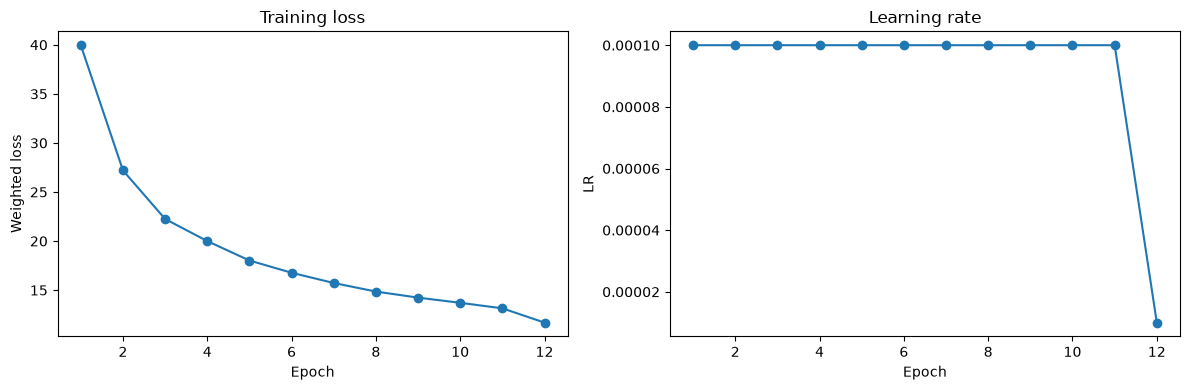

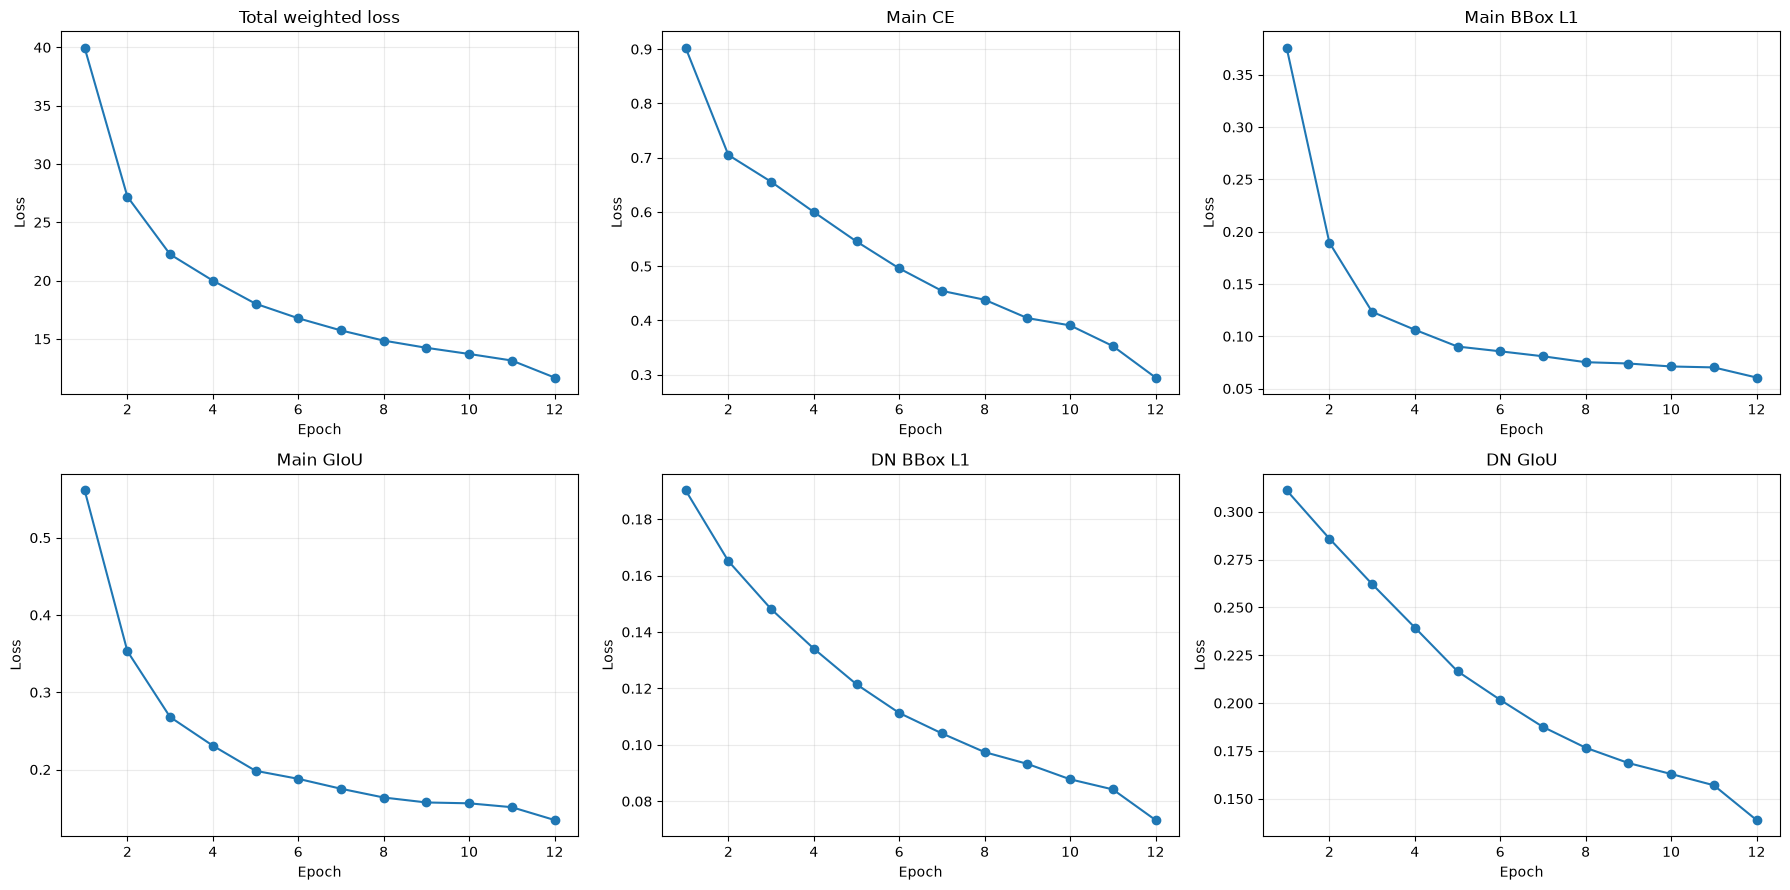

In [4]:
plot_history(config.history_path);

epochs = [row['epoch'] for row in history]
figure, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, key, title in (
    (axes[0, 0], 'loss', 'Total weighted loss'),
    (axes[0, 1], 'loss_ce', 'Main CE'),
    (axes[0, 2], 'loss_bbox', 'Main BBox L1'),
    (axes[1, 0], 'loss_giou', 'Main GIoU'),
    (axes[1, 1], 'loss_bbox_dn', 'DN BBox L1'),
    (axes[1, 2], 'loss_giou_dn', 'DN GIoU'),
):
    axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o')
    axis.set(title=title, xlabel='Epoch', ylabel='Loss')
    axis.grid(alpha=0.25)
figure.tight_layout()

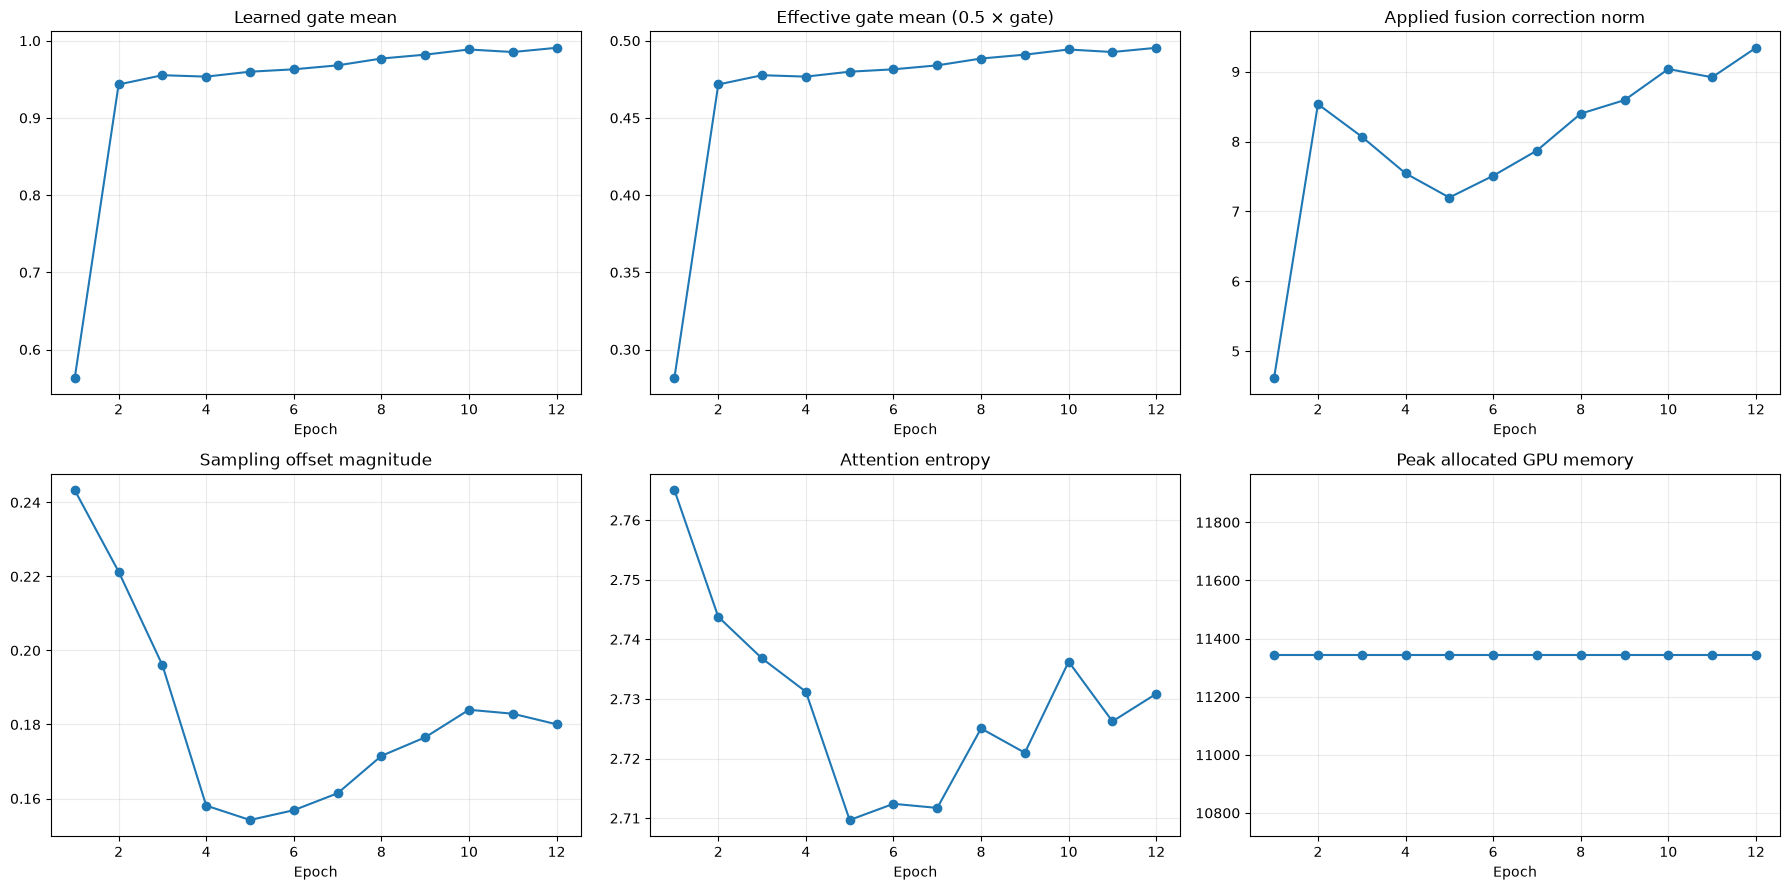

In [5]:
figure, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, key, title in (
    (axes[0, 0], 'bqr_gate_mean', 'Learned gate mean'),
    (axes[0, 1], 'bqr_effective_gate_mean', 'Effective gate mean (0.5 × gate)'),
    (axes[0, 2], 'bqr_fusion_delta_norm', 'Applied fusion correction norm'),
    (axes[1, 0], 'bqr_offset_abs_mean', 'Sampling offset magnitude'),
    (axes[1, 1], 'bqr_attention_entropy', 'Attention entropy'),
    (axes[1, 2], 'peak_cuda_mb', 'Peak allocated GPU memory'),
):
    axis.plot(epochs, [row.get(key, np.nan) for row in history], marker='o')
    axis.set(title=title, xlabel='Epoch')
    axis.grid(alpha=0.25)
figure.tight_layout()